In [5]:
!pip install imbalanced-learn==0.11.0 --no-deps --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 6.3 MB/s eta 0:00:00:00:01


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#from imblearn.over_sampling import SMOTE
from sklearn.utils import resample


import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# 📁 Set path to your folder containing .csv files
data_dir = "/kaggle/input/reduced-signal-csv/signal_csv_reduced"  # <- change this to your path

X = []
y = []

for filename in os.listdir(data_dir):
    if filename.endswith(".csv"):
        label = int(filename.split('_')[0])
        file_path = os.path.join(data_dir, filename)
        data = pd.read_csv(file_path)

        # Convert to numpy and flatten (10 channels x N) -> fixed length
        data = data.values.T
        data = data[:, :200] if data.shape[1] >= 200 else np.pad(data, ((0,0), (0, 200 - data.shape[1])), mode='constant')
        X.append(data)
        y.append(label)

X = np.array(X)  # shape: (samples, 10, 200)
y = np.array(y)

print("X shape:", X.shape)
print("Label distribution:", np.bincount(y))


X shape: (1106, 10, 200)
Label distribution: [459 417 230]


In [3]:
# Flatten X to (samples, features)
X_flat = X.reshape(X.shape[0], -1)

# Separate by class
X0 = X_flat[y == 0]
X1 = X_flat[y == 1]
X2 = X_flat[y == 2]

max_len = max(len(X0), len(X1), len(X2))

X0_up = resample(X0, replace=True, n_samples=max_len, random_state=42)
X1_up = resample(X1, replace=True, n_samples=max_len, random_state=42)
X2_up = resample(X2, replace=True, n_samples=max_len, random_state=42)

X_resampled = np.vstack([X0_up, X1_up, X2_up])
y_resampled = np.array([0]*max_len + [1]*max_len + [2]*max_len)

print("Resampled class distribution:", np.bincount(y_resampled))

# Reshape back to (samples, 10, 200)
X_resampled = X_resampled.reshape(-1, 10, 200)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


Resampled class distribution: [459 459 459]


🌲 Random Forest - Accuracy: 0.8297, Recall: 0.8298
Confusion Matrix:
 [[76 12  1]
 [18 69  6]
 [ 5  5 84]]


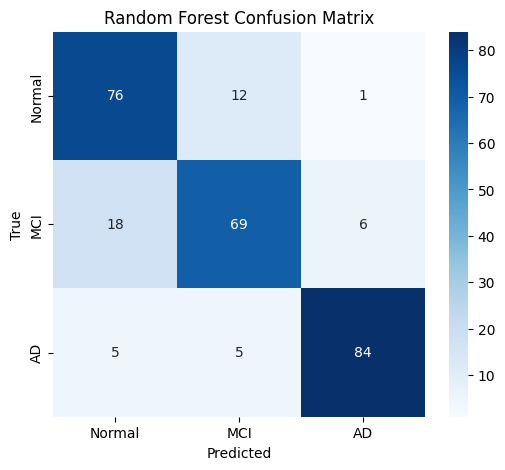

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Flatten the EEG input for scikit-learn models (samples, 10, 200) → (samples, 2000)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 🌲 Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_train)

# 🔍 Predict and Evaluate
y_pred = rf.predict(X_test_flat)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

# 📊 Print Metrics and Confusion Matrix
print(f"🌲 Random Forest - Accuracy: {acc:.4f}, Recall: {recall:.4f}")
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'MCI', 'AD'], yticklabels=['Normal', 'MCI', 'AD'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [6]:
class EEG_CNN(nn.Module):
    def __init__(self):
        super(EEG_CNN, self).__init__()
        self.conv1 = nn.Conv1d(10, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 50, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> (32, 100)
        x = self.pool(F.relu(self.conv2(x)))   # -> (64, 50)
        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [7]:
# Prepare PyTorch dataset
X_cnn = torch.tensor(X_resampled, dtype=torch.float32)
y_cnn = torch.tensor(y_resampled, dtype=torch.long)

dataset = TensorDataset(X_cnn, y_cnn)
train_len = int(0.8 * len(dataset))
train_set, val_set = random_split(dataset, [train_len, len(dataset) - train_len])
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
for xb, yb in train_loader:
    print("Shape before sending to model:", xb.shape)
    break


Shape before sending to model: torch.Size([32, 10, 200])


In [9]:

val_loader = DataLoader(val_set, batch_size=32)

# Model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEG_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
for epoch in range(10):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    val_acc = 0
    val_total = 0
    model.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(1)
            val_acc += (preds == yb).sum().item()
            val_total += yb.size(0)

    print(f"Epoch {epoch+1}/10 - Loss: {total_loss:.4f} - Train Acc: {correct/total:.4f} - Val Acc: {val_acc/val_total:.4f}")


Epoch 1/10 - Loss: 38.5319 - Train Acc: 0.3351 - Val Acc: 0.2790
Epoch 2/10 - Loss: 38.4390 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 3/10 - Loss: 38.4583 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 4/10 - Loss: 38.4395 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 5/10 - Loss: 38.4505 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 6/10 - Loss: 38.4490 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 7/10 - Loss: 38.4370 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 8/10 - Loss: 38.4483 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 9/10 - Loss: 38.4520 - Train Acc: 0.3470 - Val Acc: 0.2790
Epoch 10/10 - Loss: 38.4329 - Train Acc: 0.3470 - Val Acc: 0.2790


🧠 CNN - Accuracy: 0.3370, Recall: 0.3333
Confusion Matrix:
 [[ 0 89  0]
 [ 0 93  0]
 [ 0 94  0]]


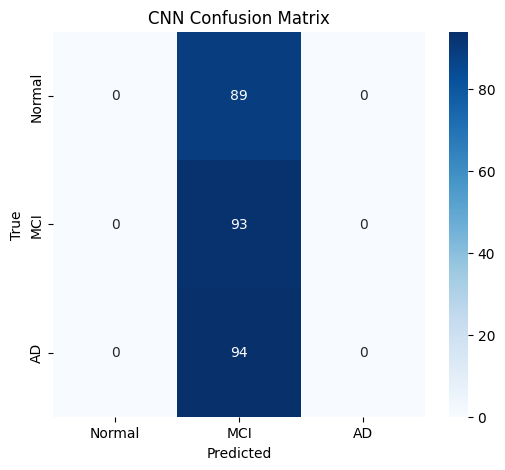

In [10]:
model.eval()
X_test_tensor = torch.tensor(X_test.reshape(-1, 10, 200), dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

with torch.no_grad():
    preds = model(X_test_tensor).argmax(1).cpu().numpy()

cnn_acc = accuracy_score(y_test, preds)
cnn_recall = recall_score(y_test, preds, average='macro')
cm = confusion_matrix(y_test, preds)

print(f"🧠 CNN - Accuracy: {cnn_acc:.4f}, Recall: {cnn_recall:.4f}")
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','MCI','AD'], yticklabels=['Normal','MCI','AD'])
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [11]:
print("🏁 Summary:")
print(f"Random Forest Accuracy: {acc:.4f}, Recall: {recall:.4f}")
print(f"CNN Accuracy: {cnn_acc:.4f}, Recall: {cnn_recall:.4f}")

if cnn_acc > acc:
    print("✅ Best Model: CNN")
else:
    print("✅ Best Model: Random Forest")


🏁 Summary:
Random Forest Accuracy: 0.8297, Recall: 0.8298
CNN Accuracy: 0.3370, Recall: 0.3333
✅ Best Model: Random Forest
